# Análisis de sobre la calidad del servicio de un problema hipotetico de una aplicación de transporte privado

Las oficinas de Uber en la CDMX desean evaluar la calidad del servicio de la aplicación en
la ciudad. <br>
Para esta evaluación del servicio, se analiza la probabilidad de que un usuario espere por
”mucho” tiempo hasta que un conductor acepte el viaje, si esta probabilidad es alta, entonces
se califica como malo al servicio de la aplicación. <br>
Esta forma de evaluación es bastante común en otros contextos, como al evaluar la eficiencia de una fila de espera, y se considera un punto
de corte para decir que la probabilidad es alta, generalmente es de 0.1. <br>
El área de Análisis de Datos de las oficinas de Uber en CDMX tiene 2693 registros del
tiempo de espera (en minutos) desde que un usuario solicita un viaje hasta que un conductor
lo acepta. <br> 
Por experiencia, los analistas saben que los tiempos de espera de los usuarios
siguen una distribución Exponencial, además de que el tiempo de espera de un usuario es
independiente del tiempo de espera de otro usuario. <br>
Los directivos de Uber definen como ”mucho” que el usuario espere más de 10 minutos. <br>
Realice el siguiente análisis, justificando detalladamente sus respuestas. <br>
Puede usar las paqueterı́as de R con libertad.

### (a) Estime el tiempo de espera promedio de un usuario, ası́ como el tiempo de espera en un dı́a con tráfico (peor escenario) y un dı́a sin tráfico (mejor escenario).

In [2]:
#Primero importemos el data frame
df_uber <- read.csv("Uber.csv")
str(df_uber)
head(df_uber)
max(df_uber$tiempos)

'data.frame':	2693 obs. of  2 variables:
 $ id     : int  1 2 3 4 5 6 7 8 9 10 ...
 $ tiempos: num  0.2982 0.1691 0.0206 0.0338 0.118 ...


id,tiempos
1,0.29822671
2,0.16913646
3,0.02058029
4,0.03375539
5,0.11804062
6,0.02828685


[1] 0.791291

Sabemos que los datos se distribuyen de manera exponencial. Es dicir: $X_{1},...,X_{2693}$ ~ $Exp{\lambda}$. (son iid) <br>
Sabemos por proba 1 que $\mathbb{E}[X]= 1/\lambda$. <br>
No conocemos el parámetro, entonces lo vamos a estimar. <br>
Por estadística 1, sabemos que dicho estimador es: $\hat{\lambda} = 1/\bar{X}$ <br>
Entonces, $\mathbb{E}[X] \approx 1/\hat{\lambda}.$

In [ ]:
#Calculemos el estimador
X_barra_1 <- mean(df_uber$tiempos) #X_barra del ejericico 1
lambda_hat <- 1 / X_barra_1

#Por tanto, nuestro tiempo esperado será 1/lambda_hat
tiempo_espera <- 1/lambda_hat

Ahora, vamos a contruir un intervalo de confianza a nuestro estimador al 95% de nivel de confianza<br>.
Por estadística 1, sabemos que dicho intervalo está dado por: <br>
$[\chi^{2}_{2n, \alpha/2}/2\sum_{i=1}^{2693}X_{i}, \chi^{2}_{2n, 1-\alpha/2}/2\sum_{i=1}^{2693}X_{i}]$

In [4]:
#Declaramos algunos valores fijos.
n <- length(df_uber$tiempos) #2693
alfa <- 0.05

#Hallamos los cuantiles.
cuantil_inferior <- qchisq(p = alfa, df = 2 * n)
cuantil_superior <- qchisq(p = 1-(alfa/2), df  = 2 * n)

#Hallamos los extremos del intervalo.
limite_inferior <- cuantil_inferior / (2*sum(df_uber$tiempos))
limite_superior <- cuantil_superior / (2*sum(df_uber$tiempos))

Ya le encontramos el intervalo de confianza a nuestro estiamador, entonces haremos lo siguiente: <br>
Para encontrar el tiempo promedio en el mejor caso, haremos lo siguiente: tiempo_espera_mejor_caso = $1/\hat{\lambda}_{min}$. <br>
Análogamente haremos lo mismo para el tiempo en el peor caso: tiempo_espera_peor_caso = $1/\hat{\lambda}_{max}$.

In [5]:
tiempo_mejor <- 1/limite_inferior
tiempo_peor <- 1/limite_superior

In [6]:
#Imprimimos resultados
print('Por lo tanto: ')
print(paste('El tiempo de espera promedio es de: ', tiempo_espera, 'minutos.'))
print(paste('El tiempo de esepra promedio sin tráfico es de: ', tiempo_mejor, 'minutos.'))
print(paste('El tiempo de esepra promedio con tráfico es de: ', tiempo_peor, 'minutos.'))

[1] "Por lo tanto: "
[1] "El tiempo de espera promedio es de:  0.0912637227270793 minutos."
[1] "El tiempo de esepra promedio sin tráfico es de:  0.0942304583961053 minutos."
[1] "El tiempo de esepra promedio con tráfico es de:  0.0879125842582596 minutos."


### (b) Estime la probabilidad de que un usuario espere mucho tiempo. En un mal dı́a, ¿cuántos usuarios esperan no más de 10 minutos? ¿Y en un buen dı́a cuántos esperan más de 10 minutos?

Sabemos lo siguiente: <br>
Si un usuario espera mucho tiempo, espera más de 10 minutos. <br>
La función de supervencia de la exponencial es: $P[X>t]= e^{-\lambda t}$

In [7]:
#Entonces, haciendo t= 10:
t <- 10 
proba_espera_alto = exp(-lambda_hat*t)
proba_espera_alto_despejado = exp(-limite_inferior*t)
proba_espera_alto_trafico = exp(-limite_superior*t)

#Imprimimos resultados
print('Por tanto:')
print(paste('La probabilidad de que la espera sea de más de 10 minutos es de:', proba_espera_alto,'.'))
print(paste('La probabilidad de que la espera sea de más de 10 minutos sin tráfico es de:', proba_espera_alto_despejado,'.'))
print(paste('La probabilidad de que la espera sea de más de 10 minutos con tráfico es de:', proba_espera_alto_trafico,'.'))

[1] "Por tanto:"
[1] "La probabilidad de que la espera sea de más de 10 minutos es de: 2.58964694764281e-48 ."
[1] "La probabilidad de que la espera sea de más de 10 minutos sin tráfico es de: 8.15556347047314e-47 ."
[1] "La probabilidad de que la espera sea de más de 10 minutos con tráfico es de: 3.97449172294946e-50 ."


### (c) ¿Se puede decir que la probabilidad de que un usuario espere 5 minutos o menos es de 0.09 (hipótesis de referencia) o que es de 0.101?

Primero, sabemos que la probabiliadd de que un usuario espere 5 minutos o menos está dada por: $P[X \leq 5]= 1- e^{-5 \lambda}$. <br>
Ahora, consideremos las siguientes hipótesis: <br>
$H_{0}: P[X \leq 5]=0.09$ vs $H_{1}: P[X \leq 5]=0.101$. <br>
Observemos lo siguiente: <br>
$H_{0}: P[X \leq 5]=0.09=1- e^{-5 \lambda}$. <br>
$H_{1}: P[X \leq 5]=0.101= 1- e^{-5 \lambda}$. <br>
Podemos despejar a $\lambda$ en ambas hipótesis. <br>
Con esto obtenemos: <br>
$H_{0}: \lambda = (-1/5)(ln(1-0.09))$ vs $H_{1}: \lambda = (-1/5)(ln(1-1.01))$. <br>
Pongamos a nuestra estadística de prueba: $T(x) = \sum_{i=1}^{2693} X_{i}$

In [8]:
#Primero encontremos la constante C que acota a nuestra estadística de prueba.
n <- length(df_uber$tiempos)
alfa <- 0.05
grados_libertad <- 2* n

c_1 <- qchisq(p = 1-alfa, df = grados_libertad)


Entonces neustra región de rechazo está dada por: $C = \set{X \in \Omega^{2693}: T(X) \geq c_{1}}$

In [9]:
#Hagamos nuestra estadística de prueba
T_prueba <- sum(df_uber$tiempos)

#Contratemos nuestra hipótesis
T_prueba < c_1

[1] TRUE

Vemos que no se rechaza $H_{0}$. <br>
Es decir, no encontramos evidencia para decir que la probabilidad de que un usuario espere más de 5 minutos es mayor o igual a 0.09. <br>
Por tanto no podemos decir que es de 0.101.

Sabemos que la distribución acumulada de la exponencial es: $P[X \leq t]=1-e^{- \lambda t}$

Por tanto, vemos que dicha probabilidad no es de 0.09 ni tampoco es de 0.101.

### (d) ¿Se puede decir que la probabilidad de que un usuario espere más de 10 minutos es distinta de 0.1? ¿Me sirve saber esto?

Sabemos que $P[X>10] = e^{- \lambda *t}$. <br>
Resolveremos este problema mediante una prueba de hipótesis. <br>
$H_{0}: P[X>10] = 0.1$ vs $H_1: P[X>10] \neq 0.1$. <br>
Observemos lo siguiente: <br>
$P[X>10] = e^{-10\lambda}$, entonces tenemos lo siguiente: <br>
$H_{0}: e^{-10\lambda} = 0.1$ vs $H_{1}: e^{-10\lambda} \neq 0.1$. <br>
Podemos despejar a $\lambda$: <br>
$H_{0}: \lambda = (-1/10)ln(0.1)$ vs $H_{1}: \lambda \neq (-1/10)ln(0.1)$. <br>
Nuestra estadística de prueba será: $T(x)=2*(-1/10)ln(0.1)\sum_{i=1}^{2693} X_{i}$


In [10]:
#Primero encontremos nuestra constante que acote a la esetadística de prueba
alfa <- 0.05
n <- length(df_uber$tiempos)
c_2 <- qchisq(p = 1-alfa, df = 2 * n)

Nuestra región de rechazo queda como: $C = \set{X \in \Omega^{2993}: T(X) \geq c_{2}}$

In [11]:
#Primero, definamos a nuestros parámetros
n <- length(df_uber$tiempos)
t <- 10
p_d <- 0.1
alfa <- 0.05
T_prueba <- (-1/10)*(log(0.1))*(sum(df_uber$tiempos))
T_prueba >= c_2



[1] FALSE

Vimos que se rechaza $H_{0}$. Es decir, no se encontró evidencia para decir que la probabilidad de que alguien espere más de 10 minutos es igual a 0.1. <br>
Más aún, sabemos por el inciso b) que dicha probabilidad es muy cercana a cero.

### (e) Concluya su análisis sobre la calidad del servicio, puede incluir algunas gráficas que ayuden a visualizar los resultados obtenidos.

Podemos concluir que el servicio es excelente debido a que hay muy bajos tiempos de espera. 

Your code contains a unicode char which cannot be displayed in your
current locale and R will silently convert it to an escaped form when the
R kernel executes this code. This can lead to subtle errors if you use
such chars to do comparisons. For more information, please see
https://github.com/IRkernel/repr/wiki/Problems-with-unicode-on-windowsRegistered S3 methods overwritten by 'ggplot2':
  method         from 
  [.quosures     rlang
  c.quosures     rlang
  print.quosures rlang



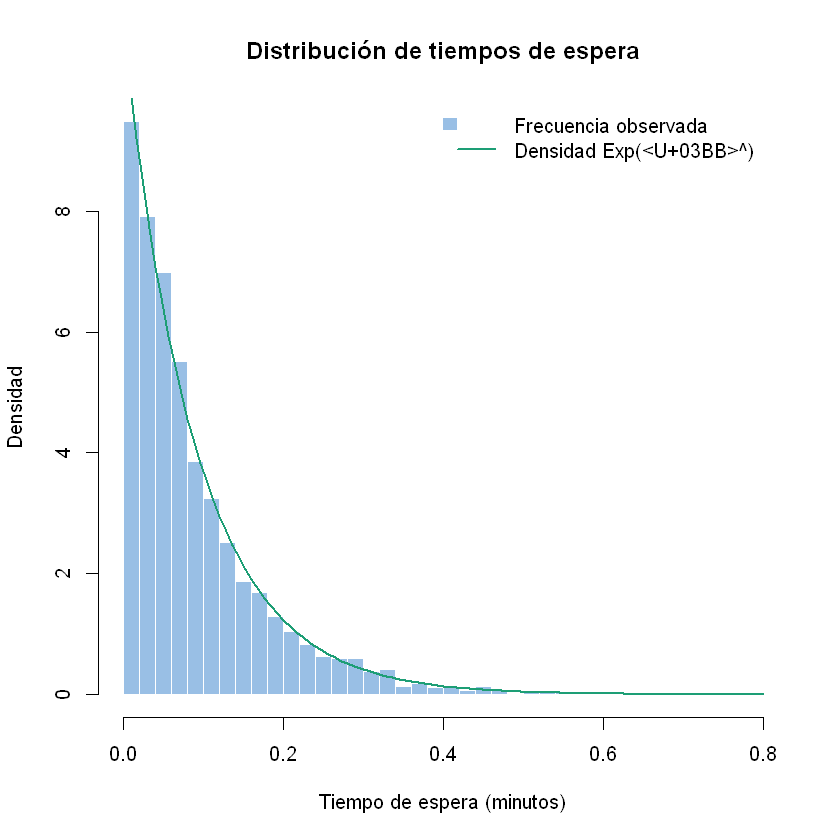

In [12]:
library(ggplot2)
hist(df_uber$tiempos,
     breaks = 40,
     probability = TRUE,
     col = rgb(0.2, 0.5, 0.8, 0.5),
     border = "white",
     main = "Distribución de tiempos de espera",
     xlab = "Tiempo de espera (minutos)",
     ylab = "Densidad")
# Curva de densidad exponencial ajustada
curve(dexp(x, rate = lambda_hat),
      col = "#1D9E75",
      lwd = 2,
      add = TRUE)


# Leyenda
legend("topright",
       legend = c("Frecuencia observada", "Densidad Exp(λ̂)"),
       fill   = c(rgb(0.2, 0.5, 0.8, 0.5), NA),
       border = c("white", NA),
       lty    = c(NA, 1, 2),
       lwd    = c(NA, 2, 1.5),
       col    = c(NA, "#1D9E75", "#E24B4A"),
       bty    = "n")

## Análisis de flujo para rentabilidad de una empresa de servicio de alimentos

Durante el año 2024, el área financiera de Casa Toño desea analizar si la franquicia aún es rentable en la CDMX, analizando el flujo neto diario por sucursal, que corresponde a la diferencia entre ingresos por ventas y gastos operativos del dı́a (sueldos, insumos, electricidad, renta, entre otros). Se pone como cuota para que las sucursales se consideren rentables que en promedio el flujo diario sea de 50,000 pesos. <br>
Debido a la naturaleza del negocio, el flujo puede tomar valores positivos o negativos. Un valor positivo indica que la sucursal obtuvo ganancias ese dı́a (muchos clientes, todos los insumos disponibles, etc.), mientras que un valor negativo indica que la sucursal registró pérdidas operativas (insumos caducados, mantenimiento de instalaciones, desperdicio de platillos preparados). <br>
El departamento de análisis recopiló 37,059 registros del flujo neto diario (en miles de pesos) de distintas sucursales de la cadena en la Ciudad de México durante 2024. Los analistas consideran razonable suponer que el flujo neto diario sigue una distribución Normal. <br>
Además, se supone que los flujos observados son independientes entre sı́. <br>
Realice el siguiente análisis, justificando detalladamente sus respuestas. Puede usar las paqueterı́as de R con libertad.

### (a) Estime el flujo promedio de una sucursal, ası́ como la variabilidad de los flujos por sucursal.

'data.frame':	37059 obs. of  3 variables:
 $ id      : int  1 2 3 4 5 6 7 8 9 10 ...
 $ flujos  : num  39.5 41.2 39.8 41.9 40.4 ...
 $ sucursal: Factor w/ 2 levels "G","NG": 2 2 1 1 2 2 2 1 2 1 ...


id,flujos,sucursal
1,39.48828,NG
2,41.23115,NG
3,39.84050,G
4,41.87135,G
5,40.39640,NG
6,41.21680,NG


[1] 30.76021

[1] 51.07613

[1] 40.00606

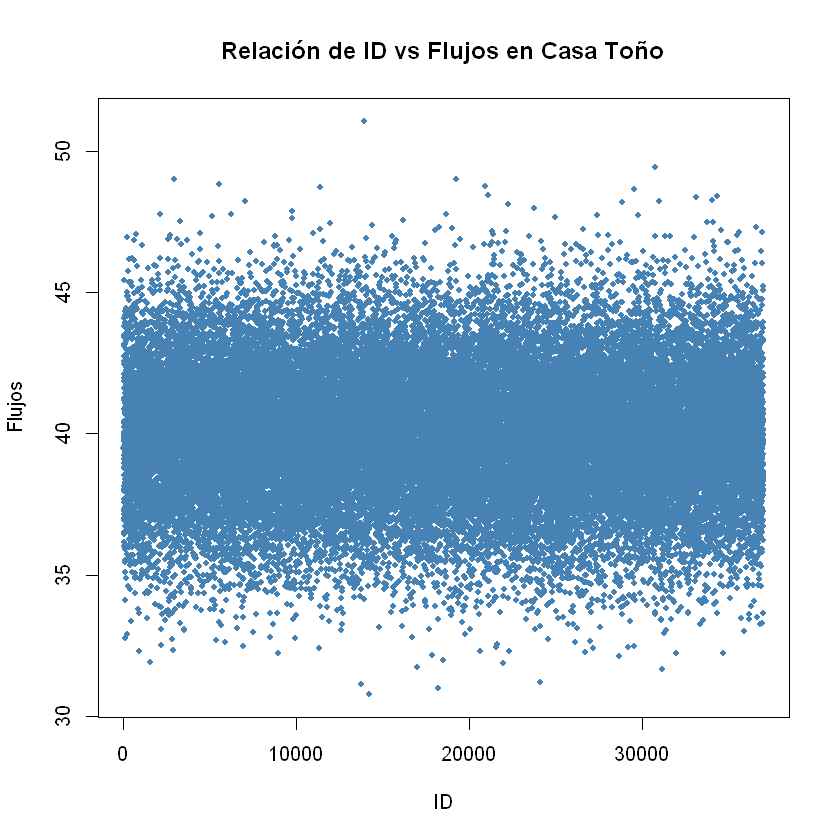

In [25]:
#Primero importemos los datos.
df_CT <- read.csv("flujosCasaToño.csv")

#Ahora, veamos agunas consideraciones básicas de los datos.
str(df_CT)
head(df_CT)
min(df_CT$flujos)
max(df_CT$flujos)
mean(df_CT$flujos)

#Ahora hagamos un gráfico para ver cómo se distribuyrn los gráficos
plot(df_CT$id, df_CT$flujos, main = "Relación de ID vs Flujos en Casa Toño", xlab = "ID", ylab = "Flujos", col = "steelblue", pch = 20)

Sabemos que la distribución de los datos sigue una distribución normal y vimos que la meida es única (no se ve multimodal). <br>
Por estadística 1, sabemos que $\bar{X} = \mu$ y además podemos encontar a $\sigma ^{2}$ como sigue: $\sigma^{2}= \sum_{i=1}^{37,059}(X_{i}-\bar{X})^{2}/n-1$

In [ ]:
#Primeor, pasemos esto a código.
X_barra_6 <- mean(df_CT$flujos) #X_barra del ejercicio 6
sigma_2_6 <- var(df_CT$flujos) #sigma_2 del ejercicio 6

Por tanto, sabemos que si nuestra muestra aleatoria ~ $N(\mu, \sigma^2)$. Entonces: <br>
$\mathbb{E}[X] = \mu$ y además, $Var[X] = \sigma^{2}$. <br>
Además como nuestras observaciones son iid, todas tienen la misma media y la misma varianza.

In [31]:
#Imprimamos nuestros resultados
print("Por lo tanto:")
print(paste("El flujo promedio de una sucursal es de: $", X_barra_6, "."))
print(paste("La variabiliad de flujos por sucursal es de: $", sigma_2_6, "."))

[1] "Por lo tanto:"
[1] "El flujo promedio de una sucursal es de: $ 40.0060550675714 ."
[1] "La variabiliad de flujos por sucursal es de: $ 5.27360902348859 ."


### (b) ¿Se puede decir que el flujo promedio es distinto de 50,000 pesos diarios? ¿Me sirve saber esto?

Este problema lo abordaremos mediante una prueba de hipótesis: <br>
$H_{0}: \mu = 50,000$ vs $H_{1}: \mu \neq 50,000$ <br>
Proponemos a la estadística de prueba: $T(x) = (\bar{X}- \mu)/(\sqrt(\sigma^{2})/\sqrt(n))$ <br>
Observamos lo siguiente: $T(x)$ ~ $t_{n-1}$ <br>
Ahora, para encontrar la c, podemos hacer lo siguiente: $c=t_{\alpha / 2, n-1 }$ <br>
Por tanto, nuestra región de rechazo queda como: 
$\set{X \in \Omega^{37059} : T(X) < -c,  T(X) >c}$

In [ ]:
#Ahora pasemos todo esto a código. 
alfa <- 0.05
n_6 <- length(df_CT$flujos)
mu_6 <- 50.000 

#Primero definamos a nuestra estadística de prueba
T_prueba_6 <- (X_barra_6 - mu_6)/(sqrt(sigma_2_6 * n_6))

#Ahora, encontremos la costante que acota a nuestra T(X)
c_6 <- qt(p = alfa / 2, df = n_6 -1)

#Ahora realicemos las pruebas: 
T_prueba_6 < -c_6
T_prueba > c_6

[1] TRUE

[1] TRUE

Por tanto, vimos que se rechaza dos veces nuestra estadística de prueba. <br>
Es decir, encontramos evidencias para afirmar que efectivamente, el flujo promedio es distinto a $50,000 pesos diarios. <br>
Dada esta información todavía no podemos decir que nos sirva, debido a que no hemos encontrado evidencias todavía si el flujo promedio es mayor o menor a $50,0000 diarios.

### (c) Un director de sucursal tiene la creencia de que el flujo no es igual para las sucursales que se encuentran en zonas gentrificadas y las sucursales que no se encuentran en zonas gentrificadas. Con la información disponible. <br> ¿Se puede decir que sus flujos promedio son diferentes?  <br> Como se está realizando una partición de la muestra original, puede suponer que las poblaciones tienen la misma varianza.

Esto se puede solucionar vía prueba de hipótesis. <br>
$H_{0}: \mu_{G} = \mu_{NG}$ vs $H_{1}: \mu_{G} \neq \mu_{NG}$, es decir: <br>
$H_{0}: \mu_{G} - \mu_{NG} = 0$ vs $H_{1}: \mu_{G} - \mu_{NG} \neq 0$.

In [42]:
#Primero definamos algunos parámetros de las zonas gentrificadas y de las no gentrificadas.
mu_G <- mean(df_CT$flujos[df_CT$sucursal == "G"])
mu_NG <-  mean(df_CT$flujos[df_CT$sucursal == "NG"])
sigma_2_G <- var(df_CT$flujos[df_CT$sucursal == "G"])
sigma_2_NG <- var(df_CT$flujos[df_CT$sucursal == "NG"])
n_G <- sum(df_CT$sucursal == "G")
n_NG <- sum(df_CT$sucursal == "NG")

print(paste("El promedio de ingresos en la zonas gentrificadas es de: $", mu_G, "."))
print(paste("El promedio de ingresos en la zonas  no gentrificadas es de: $", mu_NG, "."))


[1] "El promedio de ingresos en la zonas gentrificadas es de: $ 40.0122628154626 ."
[1] "El promedio de ingresos en la zonas  no gentrificadas es de: $ 39.9999189334483 ."


Observamos que a simple vista, los promedios de flujo no son iguales (aunque varía un poco). <br>
Sigamos con la prueba de hipótesis. <br>

In [44]:
#Construyamos la estadística de prueba
T_prueba_6_c <- ((mu_G-mu_NG)-0)/sqrt((sigma_2_G/n_G)+(sigma_2_NG/n_NG))

#Ahora, encontremos la constante que acote a nuestra estadística de prueba
alfa <- 0.05
n <- length(df_CT$sucursal)
c_6_c <- qt(p = 1-alfa/2, df = n-2)

Nuestra región de rechazo está dada por: $C = \set{X \in \Omega^37059 : T(X) \neq c_{6c}}$

In [45]:
T_prueba_6_c == c_6_c

[1] FALSE

Por tanto, encontramos evidencia que se rechaza $H_{0}$. Es decir, encontramos evidencias que, en promedio, los promedios de flujo de las sucursales en zonas gentrificadas y en zonas no gentrificadas son distintos. 

### (d) Concluya su análisis. ¿Los aspectos considerados anteriormente son suficientes para tomar una decisión?

Con la información obtenida hasta ese momento no podemos tomar una conclusión debido a que no sabemos si el ingreso promedio de cualquier sucursal es menor o mayor a $50,000 pesos diaros para poder así catalogarla como rentable o no. 